In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency, kruskal

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
FILE_PATH = Path(
    "../data/raw/張瓊之_給馬老師資料20250925_V4(遺失值不用登錄成-1).xlsx"
)

OUTPUT_DIR = Path("../results/descriptive_statistics")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not FILE_PATH.exists():
    raise FileNotFoundError(f"找不到資料檔案：{FILE_PATH.resolve()}")

print("資料檔案：", FILE_PATH.resolve())
print("輸出資料夾：", OUTPUT_DIR.resolve())

資料檔案： D:\school\研究所\馬老師\失智症2\project\data\raw\張瓊之_給馬老師資料20250925_V4(遺失值不用登錄成-1).xlsx
輸出資料夾： D:\school\研究所\馬老師\失智症2\project\results\descriptive_statistics


In [3]:
demo = pd.read_excel(FILE_PATH, sheet_name="demographic")
mmse = pd.read_excel(FILE_PATH, sheet_name="MMSE longitudinal")
casi = pd.read_excel(FILE_PATH, sheet_name="CASI longitudinal")

print("demographic shape:", demo.shape)
print("MMSE shape:", mmse.shape)
print("CASI shape:", casi.shape)

demographic shape: (1302, 10)
MMSE shape: (5550, 11)
CASI shape: (4353, 12)


In [4]:
demo = demo.iloc[1:].copy()

demo.columns = [
    "patient_id",
    "diagnosis",
    "bio_category",
    "apoe",
    "gender",
    "age_first_mmse",
    "education",
    "hypertension",
    "diabetes",
    "hyperlipidemia"
]

demo.head()

,patient_id,diagnosis,bio_category,apoe,gender,age_first_mmse,education,hypertension,diabetes,hyperlipidemia
1,1,Dementia,AD,E2/E3,0,79,0,0,1,1
2,2,Dementia,non-AD,E3/E3,1,51,12,0,1,0
3,3,MCI,non-AD,E3/E3,1,47,9,1,0,1
4,4,MCI,AD,E4/E4,0,82,8,0,1,1
5,5,Dementia,AD,E3/E3,0,72,2,0,1,1


In [5]:
mmse = mmse.rename(columns={
    "Count Number": "patient_id",
    "Date": "visit_date",
    "MMSE(numerical)": "mmse",
    "CDR (scale)": "cdr_global",
    "CDR_M (scale)": "cdr_memory",
    "CDR_O (scale)": "cdr_orientation",
    "CDR_J (scale)": "cdr_judgment",
    "CDR_C (scale)": "cdr_community",
    "CDR_H (scale)": "cdr_home_hobbies",
    "CDR_P (scale)": "cdr_personal_care",
    "CDR-SOB(numerical)": "cdr_sob"
})

mmse.head()

,patient_id,visit_date,mmse,cdr_global,cdr_memory,cdr_orientation,cdr_judgment,cdr_community,cdr_home_hobbies,cdr_personal_care,cdr_sob
0,1,2006-11-13,17,1.000,1.000,1.000,1.000,1.000,1.000,1.000,6.000
1,1,2007-08-31,15,1.000,1.000,1.000,1.000,1.000,1.000,1.000,6.000
2,1,2008-01-31,15,1.000,1.000,1.000,1.000,1.000,1.000,1.000,6.000
3,1,2008-08-14,16,1.000,1.000,1.000,1.000,1.000,1.000,0.000,5.000
4,1,2009-02-05,17,1.000,1.000,1.000,1.000,1.000,1.000,1.000,6.000


In [6]:
casi = casi.rename(columns={
    "Count Number": "patient_id",
    "Date": "visit_date",
    "MENMA10": "casi_mental_manipulation",
    "ATTEN8": "casi_attention",
    "ORIEN18": "casi_orientation",
    "LTM10": "casi_long_term_memory",
    "STM12": "casi_short_term_memory",
    "ABSTR12": "casi_abstraction",
    "DRAW10": "casi_drawing",
    "ANML10": "casi_verbal_fluency",
    "LANG10": "casi_language",
    "Total": "casi_total"
})

casi.head()

,patient_id,visit_date,casi_mental_manipulation,casi_attention,casi_orientation,casi_long_term_memory,casi_short_term_memory,casi_abstraction,casi_drawing,casi_verbal_fluency,casi_language,casi_total
0,1,2008-08-14,5,6,5,8,1.800,8,8,2,5.000,48.800
1,1,2009-02-05,1,7,7,6,2.800,7,10,0,9.000,49.300
2,1,2009-08-24,2,5,2,6,1.800,6,0,3,8.000,33.300
3,1,2010-02-04,6,5,8,10,3.000,5,4,2,8.000,51.000
4,1,2010-08-06,2,5,3,6,0.000,6,4,1,4.000,31.000


## 統一 ID、日期及數值格式

In [7]:
# 統一 patient_id
for df in [demo, mmse, casi]:
    df["patient_id"] = pd.to_numeric(
        df["patient_id"],
        errors="coerce"
    ).astype("Int64")

    df.dropna(subset=["patient_id"], inplace=True)

# 日期格式
mmse["visit_date"] = pd.to_datetime(
    mmse["visit_date"],
    errors="coerce"
)

casi["visit_date"] = pd.to_datetime(
    casi["visit_date"],
    errors="coerce"
)

# 基本資料數值欄位
demo_numeric_cols = [
    "gender",
    "age_first_mmse",
    "education",
    "hypertension",
    "diabetes",
    "hyperlipidemia"
]

for col in demo_numeric_cols:
    demo[col] = pd.to_numeric(demo[col], errors="coerce")

# MMSE/CDR 數值欄位
mmse_numeric_cols = [
    "mmse",
    "cdr_global",
    "cdr_memory",
    "cdr_orientation",
    "cdr_judgment",
    "cdr_community",
    "cdr_home_hobbies",
    "cdr_personal_care",
    "cdr_sob"
]

for col in mmse_numeric_cols:
    mmse[col] = pd.to_numeric(mmse[col], errors="coerce")

# CASI 數值欄位
casi_numeric_cols = [
    "casi_mental_manipulation",
    "casi_attention",
    "casi_orientation",
    "casi_long_term_memory",
    "casi_short_term_memory",
    "casi_abstraction",
    "casi_drawing",
    "casi_verbal_fluency",
    "casi_language",
    "casi_total"
]

for col in casi_numeric_cols:
    casi[col] = pd.to_numeric(casi[col], errors="coerce")

# -1 視為缺失
for df in [demo, mmse, casi]:
    df.replace(-1, np.nan, inplace=True)

print("完成型別轉換")

完成型別轉換


In [8]:
print("Biological category 原始值：")
display(
    demo["bio_category"]
    .astype("string")
    .value_counts(dropna=False)
    .to_frame("n")
)

Biological category 原始值：


,n
bio_category,
non-AD,618
AD,532
CU,151


In [9]:
def clean_bio_category(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    value_upper = value.upper().replace("_", "-").replace(" ", "")

    mapping = {
        "AD": "AD",
        "NON-AD": "non-AD",
        "NONAD": "non-AD",
        "CU": "CU"
    }

    return mapping.get(value_upper, value)


demo["bio_category"] = demo["bio_category"].apply(clean_bio_category)

GROUP_ORDER = ["AD", "non-AD", "CU"]

print("清理後 Biological category：")
display(
    demo["bio_category"]
    .value_counts(dropna=False)
    .reindex(GROUP_ORDER)
    .to_frame("病患數")
)

清理後 Biological category：


,病患數
bio_category,
AD,532
non-AD,618
CU,151


In [10]:
# 清理類別欄位與 APOE
def clean_apoe(value):
    if pd.isna(value):
        return np.nan

    value = str(value).upper().strip()
    value = value.replace(" ", "")
    value = value.replace("Ε", "E")

    return value


demo["apoe_clean"] = demo["apoe"].apply(clean_apoe)

demo["apoe4_count"] = demo["apoe_clean"].apply(
    lambda x: np.nan if pd.isna(x) else x.count("E4")
)

demo["apoe4_carrier"] = np.where(
    demo["apoe4_count"].isna(),
    np.nan,
    (demo["apoe4_count"] >= 1).astype(int)
)

# 只保留教授指定三組
demo = demo[
    demo["bio_category"].isin(GROUP_ORDER)
].copy()

demo["bio_category"] = pd.Categorical(
    demo["bio_category"],
    categories=GROUP_ORDER,
    ordered=True
)

print("三組病患數：")
display(
    demo.groupby("bio_category", observed=True)["patient_id"]
    .nunique()
    .to_frame("病患數")
)

三組病患數：


,病患數
bio_category,
AD,532
non-AD,618
CU,151


In [11]:
# 合理範圍檢查
# 只將明顯超出量表範圍的值設成缺失，不做補值。

def set_outside_range_to_nan(df, column, lower, upper):
    invalid = (
        df[column].notna()
        & ~df[column].between(lower, upper)
    )

    print(
        f"{column}: {invalid.sum()} 筆超出 [{lower}, {upper}]，改為缺失"
    )

    df.loc[invalid, column] = np.nan


# MMSE
set_outside_range_to_nan(mmse, "mmse", 0, 30)

# CDR global
set_outside_range_to_nan(mmse, "cdr_global", 0, 3)

# CDR-SOB
set_outside_range_to_nan(mmse, "cdr_sob", 0, 18)

# CASI total
set_outside_range_to_nan(casi, "casi_total", 0, 100)

# 基本資料
set_outside_range_to_nan(demo, "age_first_mmse", 18, 110)
set_outside_range_to_nan(demo, "education", 0, 30)

mmse: 0 筆超出 [0, 30]，改為缺失
cdr_global: 0 筆超出 [0, 3]，改為缺失
cdr_sob: 0 筆超出 [0, 18]，改為缺失
casi_total: 0 筆超出 [0, 100]，改為缺失
age_first_mmse: 0 筆超出 [18, 110]，改為缺失
education: 0 筆超出 [0, 30]，改為缺失


In [12]:
# 處理同病患、同日期重複紀錄
# 不要先刪除量表缺失，只排除沒有 ID 或日期的紀錄。同日多筆以平均值代表。
mmse = mmse.dropna(
    subset=["patient_id", "visit_date"]
).copy()

casi = casi.dropna(
    subset=["patient_id", "visit_date"]
).copy()


mmse = (
    mmse
    .groupby(
        ["patient_id", "visit_date"],
        as_index=False
    )[mmse_numeric_cols]
    .mean()
)


casi = (
    casi
    .groupby(
        ["patient_id", "visit_date"],
        as_index=False
    )[casi_numeric_cols]
    .mean()
)

print("去除同日重複後：")
print("MMSE/CDR:", mmse.shape)
print("CASI:", casi.shape)

去除同日重複後：
MMSE/CDR: (5538, 11)
CASI: (4353, 12)


In [13]:
# 合併 Biological category 與基本資料
# MMSE/CDR 和 CASI 分開建立 longitudinal stack data，不要為了畫圖先把兩張量表硬合成同一日期。

demo_features = [
    "patient_id",
    "diagnosis",
    "bio_category",
    "gender",
    "age_first_mmse",
    "education",
    "hypertension",
    "diabetes",
    "hyperlipidemia",
    "apoe_clean",
    "apoe4_count",
    "apoe4_carrier"
]

mmse_long = mmse.merge(
    demo[demo_features],
    on="patient_id",
    how="inner",
    validate="many_to_one"
)

casi_long = casi.merge(
    demo[demo_features],
    on="patient_id",
    how="inner",
    validate="many_to_one"
)

print("MMSE/CDR longitudinal shape:", mmse_long.shape)
print("CASI longitudinal shape:", casi_long.shape)

MMSE/CDR longitudinal shape: (5538, 22)
CASI longitudinal shape: (4353, 23)


In [14]:
# 建立追蹤時間 
# MMSE/CDR 以第一次 MMSE/CDR 日期為基準；CASI 以第一次 CASI 日期為基準。

def add_followup_time(df):
    df = df.sort_values(
        ["patient_id", "visit_date"]
    ).copy()

    df["baseline_date"] = (
        df.groupby("patient_id")["visit_date"]
        .transform("min")
    )

    df["time_since_baseline_days"] = (
        df["visit_date"] - df["baseline_date"]
    ).dt.days

    df["time_since_baseline_months"] = (
        df["time_since_baseline_days"] / 30.4375
    )

    df["time_since_baseline_years"] = (
        df["time_since_baseline_days"] / 365.25
    )

    df["visit_number"] = (
        df.groupby("patient_id").cumcount() + 1
    )

    return df


mmse_long = add_followup_time(mmse_long)
casi_long = add_followup_time(casi_long)

display(
    mmse_long[
        [
            "patient_id",
            "bio_category",
            "visit_date",
            "visit_number",
            "time_since_baseline_years",
            "mmse",
            "cdr_global"
        ]
    ].head(10)
)

,patient_id,bio_category,visit_date,visit_number,time_since_baseline_years,mmse,cdr_global
0,1,AD,2006-11-13,1,0.000,17.000,1.000
1,1,AD,2007-08-31,2,0.797,15.000,1.000
2,1,AD,2008-01-31,3,1.216,15.000,1.000
3,1,AD,2008-08-14,4,1.752,16.000,1.000
4,1,AD,2009-02-05,5,2.231,17.000,1.000
5,1,AD,2009-08-24,6,2.779,13.000,1.000
6,1,AD,2010-02-04,7,3.228,15.000,1.000
7,1,AD,2010-08-06,8,3.729,10.000,1.000
8,1,AD,2011-07-19,9,4.679,12.000,1.000
9,1,AD,2012-05-29,10,5.541,12.000,1.000


In [15]:
# 先檢查追蹤結構
# 這一步會幫你決定要用 3 個月、6 個月還是 12 個月切區間。

def followup_structure(df, name):
    patient_summary = (
        df.groupby(
            ["patient_id", "bio_category"],
            observed=True
        )
        .agg(
            n_visits=("visit_date", "nunique"),
            followup_years=("time_since_baseline_years", "max")
        )
        .reset_index()
    )

    print(f"\n{name}")
    print("病患數：", patient_summary["patient_id"].nunique())
    print("總觀測數：", len(df))

    display(
        patient_summary.groupby(
            "bio_category",
            observed=True
        ).agg(
            patient_n=("patient_id", "nunique"),
            visits_median=("n_visits", "median"),
            visits_q1=("n_visits", lambda x: x.quantile(0.25)),
            visits_q3=("n_visits", lambda x: x.quantile(0.75)),
            followup_median=("followup_years", "median"),
            followup_q1=("followup_years", lambda x: x.quantile(0.25)),
            followup_q3=("followup_years", lambda x: x.quantile(0.75))
        )
    )

    return patient_summary


mmse_followup = followup_structure(mmse_long, "MMSE/CDR")
casi_followup = followup_structure(casi_long, "CASI")


MMSE/CDR
病患數： 1297
總觀測數： 5538


,patient_n,visits_median,visits_q1,visits_q3,followup_median,followup_q1,followup_q3
bio_category,,,,,,,
AD,532,4.000,2.000,7.000,2.886,0.926,6.236
non-AD,618,3.000,1.000,6.000,2.033,0.000,5.767
CU,147,1.000,1.000,3.000,0.000,0.000,1.684



CASI
病患數： 917
總觀測數： 4353


,patient_n,visits_median,visits_q1,visits_q3,followup_median,followup_q1,followup_q3
bio_category,,,,,,,
AD,418,4.000,2.000,7.000,3.890,1.155,6.847
non-AD,428,4.000,2.000,7.000,3.146,0.975,7.017
CU,71,1.000,1.000,3.000,0.000,0.000,2.730


In [38]:
# 建立時間區間
# 先使用每 6 個月一期。之後若後期人數太少，可以改成 12 個月

""" 
T1：0 至未滿 6 個月
T2：6 至未滿 12 個月
T3：12 至未滿 18 個月"""

BIN_MONTHS = 12

def add_time_category(df, bin_months=6):
    df = df.copy()

    bin_number = np.floor(
        df["time_since_baseline_months"] / bin_months
    ).astype("Int64") + 1

    df["time_category_number"] = bin_number
    df["time_category"] = "T" + bin_number.astype(str)

    df["time_mid_years"] = (
        (bin_number - 0.5) * bin_months / 12
    )

    return df


mmse_long = add_time_category(mmse_long, BIN_MONTHS)
casi_long = add_time_category(casi_long, BIN_MONTHS)

print(
    mmse_long["time_category"]
    .value_counts()
    .sort_index()
)

time_category
T1     1813
T10     126
T11      85
T12      70
T13      58
T14      47
T15      33
T16      21
T17      11
T18       4
T19       1
T2      785
T20       1
T21       1
T3      592
T4      492
T5      390
T6      339
T7      284
T8      227
T9      158
Name: count, dtype: int64


In [28]:
# 產生三組樣本與觀測數檢查表

group_count_table = (
    demo.groupby("bio_category", observed=True)
    .agg(
        patient_n=("patient_id", "nunique")
    )
    .reset_index()
)

mmse_observations = (
    mmse_long.groupby("bio_category", observed=True)
    .agg(
        mmse_cdr_observation_n=("visit_date", "size"),
        mmse_patient_n=("patient_id", "nunique")
    )
    .reset_index()
)

casi_observations = (
    casi_long.groupby("bio_category", observed=True)
    .agg(
        casi_observation_n=("visit_date", "size"),
        casi_patient_n=("patient_id", "nunique")
    )
    .reset_index()
)

group_count_table = (
    group_count_table
    .merge(mmse_observations, on="bio_category", how="left")
    .merge(casi_observations, on="bio_category", how="left")
)

display(group_count_table)

,bio_category,patient_n,mmse_cdr_observation_n,mmse_patient_n,casi_observation_n,casi_patient_n
0,AD,532,2600,532,2144,418
1,non-AD,618,2646,618,2059,428
2,CU,151,292,147,150,71


In [29]:
# 建立每位病患的基準資料
# 表 4.1 必須一位病患一列，不能讓追蹤次數多的人重複出現。

# 第一次 MMSE/CDR 觀測
baseline_mmse = (
    mmse_long
    .sort_values(["patient_id", "visit_date"])
    .groupby("patient_id", as_index=False)
    .first()[
        [
            "patient_id",
            "mmse",
            "cdr_global",
            "cdr_sob"
        ]
    ]
    .rename(columns={
        "mmse": "baseline_mmse",
        "cdr_global": "baseline_cdr_global",
        "cdr_sob": "baseline_cdr_sob"
    })
)

# 第一次 CASI 觀測
baseline_casi = (
    casi_long
    .sort_values(["patient_id", "visit_date"])
    .groupby("patient_id", as_index=False)
    .first()[
        ["patient_id", "casi_total"]
    ]
    .rename(columns={
        "casi_total": "baseline_casi"
    })
)

# 每位病患追蹤結構
patient_mmse_structure = (
    mmse_long.groupby("patient_id")
    .agg(
        mmse_cdr_visit_n=("visit_date", "nunique"),
        mmse_cdr_followup_years=("time_since_baseline_years", "max")
    )
    .reset_index()
)

patient_casi_structure = (
    casi_long.groupby("patient_id")
    .agg(
        casi_visit_n=("visit_date", "nunique"),
        casi_followup_years=("time_since_baseline_years", "max")
    )
    .reset_index()
)

baseline_df = (
    demo
    .merge(baseline_mmse, on="patient_id", how="left")
    .merge(baseline_casi, on="patient_id", how="left")
    .merge(patient_mmse_structure, on="patient_id", how="left")
    .merge(patient_casi_structure, on="patient_id", how="left")
)

print("基準資料病患數：", baseline_df["patient_id"].nunique())
display(baseline_df.head())

基準資料病患數： 1301


,patient_id,diagnosis,bio_category,apoe,gender,age_first_mmse,education,hypertension,diabetes,hyperlipidemia,apoe_clean,apoe4_count,apoe4_carrier,baseline_mmse,baseline_cdr_global,baseline_cdr_sob,baseline_casi,mmse_cdr_visit_n,mmse_cdr_followup_years,casi_visit_n,casi_followup_years
0,1,Dementia,AD,E2/E3,0,79.000,0.000,0.000,1.000,1.000,E2/E3,0.000,0.000,17.000,1.000,6.000,48.800,17.000,12.402,13.000,10.650
1,2,Dementia,non-AD,E3/E3,1,51.000,12.000,0.000,1.000,0.000,E3/E3,0.000,0.000,23.000,0.500,2.000,88.700,20.000,14.420,13.000,10.404
2,3,MCI,non-AD,E3/E3,1,47.000,9.000,1.000,0.000,1.000,E3/E3,0.000,0.000,29.000,0.500,1.500,93.000,23.000,18.201,19.000,17.708
3,4,MCI,AD,E4/E4,0,82.000,8.000,0.000,1.000,1.000,E4/E4,2.000,1.000,25.000,0.500,3.500,78.700,11.000,4.170,6.000,4.170
4,5,Dementia,AD,E3/E3,0,72.000,2.000,0.000,1.000,1.000,E3/E3,0.000,0.000,18.000,0.500,2.000,57.200,19.000,13.092,15.000,11.201


In [30]:
# 表 4.1 的格式化函數
def format_mean_sd(series, digits=1):
    values = pd.to_numeric(series, errors="coerce").dropna()

    if len(values) == 0:
        return "NA"

    return f"{values.mean():.{digits}f} ± {values.std(ddof=1):.{digits}f}"


def format_median_iqr(series, digits=1):
    values = pd.to_numeric(series, errors="coerce").dropna()

    if len(values) == 0:
        return "NA"

    q1 = values.quantile(0.25)
    median = values.median()
    q3 = values.quantile(0.75)

    return (
        f"{median:.{digits}f} "
        f"({q1:.{digits}f}, {q3:.{digits}f})"
    )


def format_n_percent(series, target=1, digits=1):
    valid = series.dropna()

    if len(valid) == 0:
        return "NA"

    n = (valid == target).sum()
    percent = 100 * n / len(valid)

    return f"{n} ({percent:.{digits}f}%)"


def kruskal_pvalue(df, variable):
    groups = [
        df.loc[
            df["bio_category"] == group,
            variable
        ].dropna()
        for group in GROUP_ORDER
    ]

    groups = [x for x in groups if len(x) > 0]

    if len(groups) < 2:
        return np.nan

    try:
        return kruskal(*groups).pvalue
    except ValueError:
        return np.nan


def chi_square_pvalue(df, variable):
    table = pd.crosstab(
        df["bio_category"],
        df[variable]
    )

    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan

    try:
        return chi2_contingency(table)[1]
    except ValueError:
        return np.nan


def format_pvalue(p):
    if pd.isna(p):
        return "NA"

    if p < 0.001:
        return "<0.001"

    return f"{p:.3f}"

In [31]:
# 建立表 4.1

table1_rows = []


def add_continuous_row(
    label,
    variable,
    summary_type="mean_sd",
    digits=1
):
    if summary_type == "mean_sd":
        formatter = lambda x: format_mean_sd(x, digits)
    else:
        formatter = lambda x: format_median_iqr(x, digits)

    row = {
        "變數": label,
        "整體": formatter(baseline_df[variable])
    }

    for group in GROUP_ORDER:
        group_data = baseline_df.loc[
            baseline_df["bio_category"] == group,
            variable
        ]

        row[group] = formatter(group_data)

    row["p 值"] = format_pvalue(
        kruskal_pvalue(baseline_df, variable)
    )

    table1_rows.append(row)


def add_binary_row(label, variable, target=1):
    row = {
        "變數": label,
        "整體": format_n_percent(
            baseline_df[variable],
            target=target
        )
    }

    for group in GROUP_ORDER:
        group_data = baseline_df.loc[
            baseline_df["bio_category"] == group,
            variable
        ]

        row[group] = format_n_percent(
            group_data,
            target=target
        )

    row["p 值"] = format_pvalue(
        chi_square_pvalue(baseline_df, variable)
    )

    table1_rows.append(row)


# 病患人數
n_row = {
    "變數": "病患人數",
    "整體": str(baseline_df["patient_id"].nunique()),
    "p 值": ""
}

for group in GROUP_ORDER:
    n_row[group] = str(
        baseline_df.loc[
            baseline_df["bio_category"] == group,
            "patient_id"
        ].nunique()
    )

table1_rows.append(n_row)

# 基本特徵
add_continuous_row("第一次 MMSE 年齡（歲）", "age_first_mmse")
add_binary_row("男性，n (%)", "gender", target=1)
add_continuous_row("教育年數", "education")
add_binary_row("APOE ε4 carrier，n (%)", "apoe4_carrier", target=1)
add_binary_row("高血壓，n (%)", "hypertension", target=1)
add_binary_row("糖尿病，n (%)", "diabetes", target=1)
add_binary_row("高血脂，n (%)", "hyperlipidemia", target=1)

# 基準量表
add_continuous_row("基準 MMSE", "baseline_mmse")
add_continuous_row("基準 CASI", "baseline_casi")
add_continuous_row(
    "基準 CDR global",
    "baseline_cdr_global",
    summary_type="median_iqr"
)
add_continuous_row(
    "基準 CDR-SOB",
    "baseline_cdr_sob",
    summary_type="median_iqr"
)

# 追蹤結構
add_continuous_row(
    "MMSE/CDR 測量次數",
    "mmse_cdr_visit_n",
    summary_type="median_iqr"
)
add_continuous_row(
    "MMSE/CDR 追蹤時間（年）",
    "mmse_cdr_followup_years",
    summary_type="median_iqr"
)
add_continuous_row(
    "CASI 測量次數",
    "casi_visit_n",
    summary_type="median_iqr"
)
add_continuous_row(
    "CASI 追蹤時間（年）",
    "casi_followup_years",
    summary_type="median_iqr"
)

table1 = pd.DataFrame(table1_rows)

display(table1)

,變數,整體,p 值,AD,non-AD,CU
0,病患人數,1301,,532,618,151
1,第一次 MMSE 年齡（歲）,68.7 ± 9.3,<0.001,71.4 ± 8.6,68.1 ± 8.8,62.3 ± 10.3
2,男性，n (%),565 (43.4%),<0.001,185 (34.8%),308 (49.8%),72 (47.7%)
3,教育年數,9.2 ± 4.9,<0.001,8.3 ± 5.0,9.2 ± 4.8,12.6 ± 3.7
4,APOE ε4 carrier，n (%),318 (28.7%),<0.001,210 (44.1%),89 (17.5%),19 (15.4%)
5,高血壓，n (%),426 (36.8%),0.246,173 (35.0%),215 (39.2%),38 (32.8%)
6,糖尿病，n (%),368 (31.8%),0.011,158 (32.0%),187 (34.1%),23 (19.8%)
7,高血脂，n (%),281 (24.2%),0.206,110 (22.3%),146 (26.6%),25 (21.6%)
8,基準 MMSE,22.3 ± 6.4,<0.001,20.0 ± 6.5,22.9 ± 6.0,28.2 ± 1.6
9,基準 CASI,72.8 ± 19.9,<0.001,66.8 ± 20.8,75.4 ± 17.8,92.4 ± 5.7


In [32]:
# 建立各時間點量表統計函數

def create_timepoint_summary(
    df,
    outcome,
    digits=1
):
    rows = []

    category_numbers = sorted(
        df["time_category_number"]
        .dropna()
        .astype(int)
        .unique()
    )

    for category_number in category_numbers:
        temp = df[
            df["time_category_number"] == category_number
        ].copy()

        available_n = temp[outcome].notna().sum()
        missing_n = temp[outcome].isna().sum()
        total_n = len(temp)

        missing_percent = (
            100 * missing_n / total_n
            if total_n > 0
            else np.nan
        )

        row = {
            "時間點": f"T{category_number}",
            "時間範圍（月）": (
                f"{(category_number - 1) * BIN_MONTHS}–"
                f"<{category_number * BIN_MONTHS}"
            ),
            "可用 N": int(available_n),
            "缺失 N (%)": (
                f"{missing_n} ({missing_percent:.1f}%)"
            ),
            "整體": format_mean_sd(
                temp[outcome],
                digits=digits
            )
        }

        for group in GROUP_ORDER:
            group_values = temp.loc[
                temp["bio_category"] == group,
                outcome
            ]

            row[group] = format_mean_sd(
                group_values,
                digits=digits
            )

        row["p 值"] = format_pvalue(
            kruskal_pvalue(temp, outcome)
        )

        rows.append(row)

    return pd.DataFrame(rows)

In [33]:
# 建立 MMSE、CASI、CDR 表

table_mmse = create_timepoint_summary(
    mmse_long,
    outcome="mmse",
    digits=1
)

table_casi = create_timepoint_summary(
    casi_long,
    outcome="casi_total",
    digits=1
)

table_cdr = create_timepoint_summary(
    mmse_long,
    outcome="cdr_global",
    digits=2
)

table_cdr_sob = create_timepoint_summary(
    mmse_long,
    outcome="cdr_sob",
    digits=1
)

print("表 4.2 型：MMSE")
display(table_mmse)

print("表 4.3 型：CASI")
display(table_casi)

print("表 4.4 型：CDR global")
display(table_cdr)

print("補充表：CDR-SOB")
display(table_cdr_sob)

表 4.2 型：MMSE


,時間點,時間範圍（月）,可用 N,缺失 N (%),整體,AD,non-AD,CU,p 值
0,T1,0–<18,2194,0 (0.0%),21.9 ± 6.5,19.7 ± 6.5,22.8 ± 5.9,28.2 ± 1.6,<0.001
1,T2,18–<36,996,0 (0.0%),19.7 ± 7.3,17.4 ± 7.2,21.6 ± 6.6,28.6 ± 1.3,<0.001
2,T3,36–<54,672,0 (0.0%),18.4 ± 8.0,16.2 ± 7.8,20.5 ± 7.5,28.3 ± 1.7,<0.001
3,T4,54–<72,549,0 (0.0%),17.8 ± 8.1,14.7 ± 7.9,20.7 ± 7.0,27.8 ± 2.1,<0.001
4,T5,72–<90,391,0 (0.0%),16.6 ± 9.0,12.6 ± 8.4,20.3 ± 7.8,28.6 ± 0.9,<0.001
5,T6,90–<108,278,0 (0.0%),16.2 ± 8.8,11.8 ± 8.2,20.5 ± 6.8,26.8 ± 3.1,<0.001
6,T7,108–<126,166,0 (0.0%),15.4 ± 9.5,9.5 ± 7.9,20.1 ± 7.8,25.2 ± 3.0,<0.001
7,T8,126–<144,115,0 (0.0%),15.5 ± 9.3,9.5 ± 8.1,20.2 ± 7.3,26.0 ± nan,<0.001
8,T9,144–<162,77,0 (0.0%),15.4 ± 10.0,9.5 ± 10.2,19.4 ± 7.6,28.0 ± nan,<0.001
9,T10,162–<180,61,0 (0.0%),14.0 ± 10.1,6.9 ± 9.6,18.4 ± 7.7,NA,<0.001


表 4.3 型：CASI


,時間點,時間範圍（月）,可用 N,缺失 N (%),整體,AD,non-AD,CU,p 值
0,T1,0–<18,1586,0 (0.0%),71.1 ± 20.5,65.2 ± 21.2,74.6 ± 18.3,92.0 ± 5.7,<0.001
1,T2,18–<36,805,0 (0.0%),64.1 ± 24.7,56.8 ± 24.4,70.3 ± 22.7,93.1 ± 4.4,<0.001
2,T3,36–<54,574,0 (0.0%),61.2 ± 26.9,54.9 ± 26.2,67.0 ± 25.9,93.0 ± 4.2,<0.001
3,T4,54–<72,465,0 (0.0%),58.6 ± 27.7,47.8 ± 27.2,69.0 ± 23.6,89.7 ± 8.0,<0.001
4,T5,72–<90,331,0 (0.0%),56.4 ± 29.9,42.6 ± 28.9,68.8 ± 24.4,94.3 ± 3.5,<0.001
5,T6,90–<108,254,0 (0.0%),52.6 ± 30.0,38.6 ± 28.5,66.6 ± 24.1,86.7 ± 6.1,<0.001
6,T7,108–<126,130,0 (0.0%),52.3 ± 33.1,31.5 ± 29.5,67.9 ± 26.2,86.3 ± 10.2,<0.001
7,T8,126–<144,96,0 (0.0%),50.5 ± 31.6,31.9 ± 28.3,66.9 ± 24.5,NA,<0.001
8,T9,144–<162,51,0 (0.0%),48.4 ± 33.3,28.2 ± 31.7,63.1 ± 25.9,81.0 ± nan,0.001
9,T10,162–<180,40,0 (0.0%),47.2 ± 36.5,12.2 ± 23.6,70.5 ± 21.9,NA,<0.001


表 4.4 型：CDR global


,時間點,時間範圍（月）,可用 N,缺失 N (%),整體,AD,non-AD,CU,p 值
0,T1,0–<18,2194,0 (0.0%),0.55 ± 0.45,0.67 ± 0.46,0.55 ± 0.42,0.01 ± 0.08,<0.001
1,T2,18–<36,996,0 (0.0%),0.73 ± 0.53,0.87 ± 0.56,0.63 ± 0.46,0.15 ± 0.23,<0.001
2,T3,36–<54,672,0 (0.0%),0.83 ± 0.61,0.96 ± 0.62,0.72 ± 0.55,0.00 ± 0.00,<0.001
3,T4,54–<72,549,0 (0.0%),0.89 ± 0.62,1.08 ± 0.66,0.73 ± 0.50,0.12 ± 0.22,<0.001
4,T5,72–<90,391,0 (0.0%),1.03 ± 0.71,1.29 ± 0.75,0.80 ± 0.54,0.06 ± 0.18,<0.001
5,T6,90–<108,278,0 (0.0%),1.09 ± 0.71,1.41 ± 0.78,0.77 ± 0.43,0.30 ± 0.27,<0.001
6,T7,108–<126,166,0 (0.0%),1.17 ± 0.79,1.61 ± 0.81,0.82 ± 0.57,0.38 ± 0.25,<0.001
7,T8,126–<144,115,0 (0.0%),1.10 ± 0.72,1.50 ± 0.77,0.79 ± 0.48,0.50 ± nan,<0.001
8,T9,144–<162,77,0 (0.0%),1.08 ± 0.77,1.53 ± 0.86,0.77 ± 0.50,0.50 ± nan,<0.001
9,T10,162–<180,61,0 (0.0%),1.18 ± 0.80,1.80 ± 0.85,0.80 ± 0.47,NA,<0.001


補充表：CDR-SOB


,時間點,時間範圍（月）,可用 N,缺失 N (%),整體,AD,non-AD,CU,p 值
0,T1,0–<18,2144,50 (2.3%),2.4 ± 2.9,3.2 ± 3.1,2.1 ± 2.7,0.0 ± 0.1,<0.001
1,T2,18–<36,996,0 (0.0%),3.7 ± 3.7,4.7 ± 3.9,2.8 ± 3.1,0.2 ± 0.3,<0.001
2,T3,36–<54,672,0 (0.0%),4.5 ± 4.2,5.6 ± 4.2,3.5 ± 3.9,0.0 ± 0.0,<0.001
3,T4,54–<72,549,0 (0.0%),4.9 ± 4.3,6.5 ± 4.5,3.5 ± 3.6,0.2 ± 0.5,<0.001
4,T5,72–<90,391,0 (0.0%),5.9 ± 5.1,8.1 ± 5.2,3.9 ± 4.1,0.1 ± 0.4,<0.001
5,T6,90–<108,278,0 (0.0%),6.1 ± 5.1,8.6 ± 5.3,3.7 ± 3.5,0.6 ± 0.8,<0.001
6,T7,108–<126,166,0 (0.0%),6.6 ± 5.6,9.9 ± 5.4,4.1 ± 4.2,0.6 ± 0.6,<0.001
7,T8,126–<144,115,0 (0.0%),6.2 ± 5.2,9.3 ± 5.4,3.7 ± 3.4,0.5 ± nan,<0.001
8,T9,144–<162,77,0 (0.0%),6.5 ± 5.6,10.0 ± 5.8,4.2 ± 3.9,0.5 ± nan,<0.001
9,T10,162–<180,61,0 (0.0%),7.2 ± 5.8,11.8 ± 5.9,4.4 ± 3.6,NA,<0.001


In [34]:
# 檢查各時間點三組人數
# 後期樣本太少時，平均線會非常不穩定。

def count_by_time_and_group(df, outcome):
    return (
        df.dropna(subset=[outcome])
        .groupby(
            ["time_category", "bio_category"],
            observed=True
        )["patient_id"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=GROUP_ORDER)
    )


mmse_n_table = count_by_time_and_group(
    mmse_long,
    "mmse"
)

casi_n_table = count_by_time_and_group(
    casi_long,
    "casi_total"
)

cdr_n_table = count_by_time_and_group(
    mmse_long,
    "cdr_global"
)

print("MMSE 各時間點病患數")
display(mmse_n_table)

print("CASI 各時間點病患數")
display(casi_n_table)

print("CDR 各時間點病患數")
display(cdr_n_table)

MMSE 各時間點病患數


bio_category,AD,non-AD,CU
time_category,,,
T1,532,618,147
T10,16,22,0
T11,5,16,0
T12,1,6,0
T13,0,1,0
T14,0,1,0
T2,326,315,33
T3,238,208,14
T4,179,171,10


CASI 各時間點病患數


bio_category,AD,non-AD,CU
time_category,,,
T1,418,428,71
T10,12,17,0
T11,3,11,0
T12,0,3,0
T2,279,260,20
T3,217,187,10
T4,166,157,10
T5,122,121,6
T6,87,87,4


CDR 各時間點病患數


bio_category,AD,non-AD,CU
time_category,,,
T1,532,618,147
T10,16,22,0
T11,5,16,0
T12,1,6,0
T13,0,1,0
T14,0,1,0
T2,326,315,33
T3,238,208,14
T4,179,171,10


In [35]:
# 建立趨勢圖資料
""" 
同一病患在同一時間區間可能有多筆紀錄。為避免回診較密集者權重過高，先計算：

每位病患、每個時間區間的平均分數

再計算三組平均。"""

def create_plot_summary(df, outcome):
    # 每位病患在每個時間區間只貢獻一個平均值
    patient_period = (
        df.groupby(
            [
                "patient_id",
                "bio_category",
                "time_category_number"
            ],
            observed=True,
            as_index=False
        )
        .agg(
            patient_period_value=(outcome, "mean")
        )
    )

    summary = (
        patient_period
        .groupby(
            [
                "bio_category",
                "time_category_number"
            ],
            observed=True,
            as_index=False
        )
        .agg(
            mean=("patient_period_value", "mean"),
            sd=("patient_period_value", "std"),
            n=("patient_period_value", "count")
        )
    )

    summary["se"] = summary["sd"] / np.sqrt(summary["n"])
    summary["lower_95"] = summary["mean"] - 1.96 * summary["se"]
    summary["upper_95"] = summary["mean"] + 1.96 * summary["se"]

    summary["time_mid_years"] = (
        (summary["time_category_number"] - 0.5)
        * BIN_MONTHS / 12
    )

    return summary


plot_mmse = create_plot_summary(
    mmse_long,
    "mmse"
)

plot_casi = create_plot_summary(
    casi_long,
    "casi_total"
)

plot_cdr = create_plot_summary(
    mmse_long,
    "cdr_global"
)

display(plot_mmse.head())

,bio_category,time_category_number,mean,sd,n,se,lower_95,upper_95,time_mid_years
0,AD,1,19.702,6.570,532,0.285,19.144,20.261,0.750
1,AD,2,17.592,7.145,326,0.396,16.817,18.368,2.250
2,AD,3,15.725,7.850,238,0.509,14.727,16.722,3.750
3,AD,4,14.791,8.052,179,0.602,13.611,15.971,5.250
4,AD,5,12.722,8.438,136,0.724,11.304,14.140,6.750


In [36]:
# 畫圖函數
def plot_longitudinal_trend(
    summary_df,
    outcome_label,
    title,
    filename,
    y_limits=None,
    annotate_n=True
):
    fig, ax = plt.subplots(figsize=(10, 6))

    for group in GROUP_ORDER:
        group_df = (
            summary_df[
                summary_df["bio_category"] == group
            ]
            .sort_values("time_mid_years")
        )

        if group_df.empty:
            continue

        ax.plot(
            group_df["time_mid_years"],
            group_df["mean"],
            marker="o",
            linewidth=2,
            label=group
        )

        ax.fill_between(
            group_df["time_mid_years"].to_numpy(dtype=float),
            group_df["lower_95"].to_numpy(dtype=float),
            group_df["upper_95"].to_numpy(dtype=float),
            alpha=0.15
        )

        if annotate_n:
            for _, row in group_df.iterrows():
                if pd.notna(row["mean"]):
                    ax.annotate(
                        f"n={int(row['n'])}",
                        (
                            row["time_mid_years"],
                            row["mean"]
                        ),
                        textcoords="offset points",
                        xytext=(0, 7),
                        ha="center",
                        fontsize=8
                    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("距離各量表第一次測量之追蹤時間（年）")
    ax.set_ylabel(outcome_label)

    if y_limits is not None:
        ax.set_ylim(y_limits)

    ax.legend(title="Biological category")
    ax.grid(alpha=0.25)
    fig.tight_layout()

    output_path = FIGURE_DIR / filename
    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("圖片已儲存：", output_path.resolve())

C:\Users\User\AppData\Local\Temp\ipykernel_36568\2980473917.py:62: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_36568\2980473917.py:62: UserWarning: Glyph 38626 (\N{CJK UNIFIED IDEOGRAPH-96E2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_36568\2980473917.py:62: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_36568\2980473917.py:62: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_36568\2980473917.py:62: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_36568\2980473917.py:62: UserWarning: Glyph 31532 (\N{CJK 

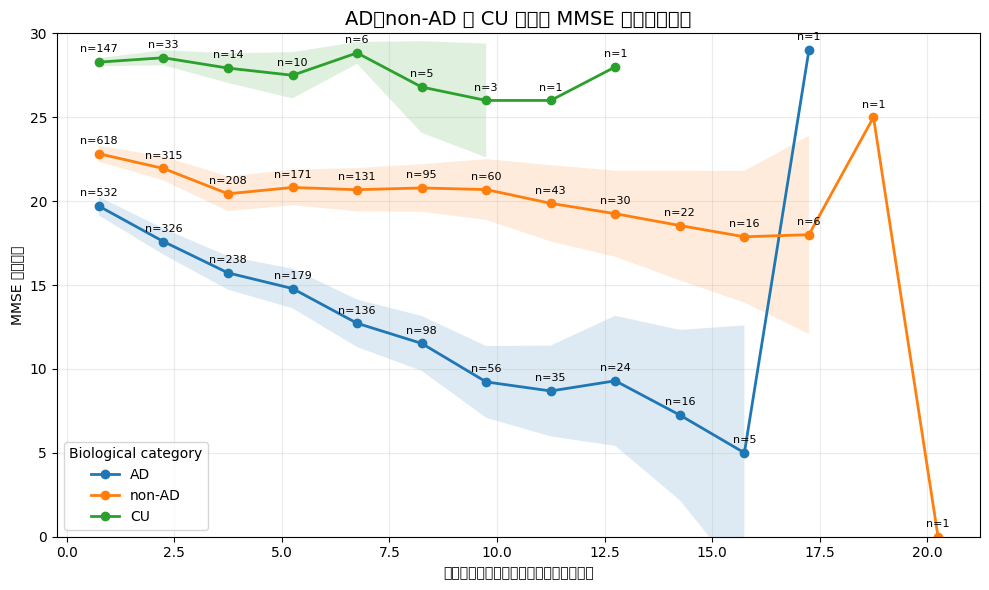

圖片已儲存： D:\school\研究所\馬老師\失智症2\project\results\descriptive_statistics\figures\MMSE_longitudinal_trend.png


In [37]:
# MMSE 縱向趨勢圖

plot_longitudinal_trend(
    summary_df=plot_mmse,
    outcome_label="MMSE 平均分數",
    title="AD、non-AD 與 CU 三組之 MMSE 縱向變化趨勢",
    filename="MMSE_longitudinal_trend.png",
    y_limits=(0, 30)
)



C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 38626 (\N{CJK UNIFIED IDEOGRAPH-96E2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 31532 (\N{CJK 

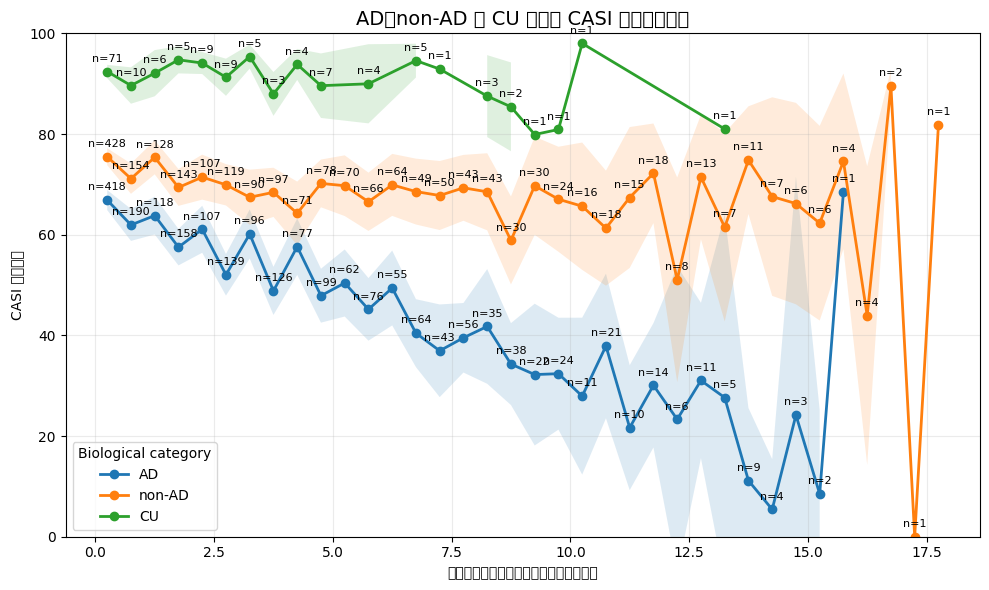

圖片已儲存： D:\school\研究所\馬老師\失智症2\project\results\descriptive_statistics\figures\CASI_longitudinal_trend.png


In [28]:
# CASI 縱向趨勢圖

plot_longitudinal_trend(
    summary_df=plot_casi,
    outcome_label="CASI 平均分數",
    title="AD、non-AD 與 CU 三組之 CASI 縱向變化趨勢",
    filename="CASI_longitudinal_trend.png",
    y_limits=(0, 100)
)



C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 38626 (\N{CJK UNIFIED IDEOGRAPH-96E2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28820\2980473917.py:62: UserWarning: Glyph 31532 (\N{CJK 

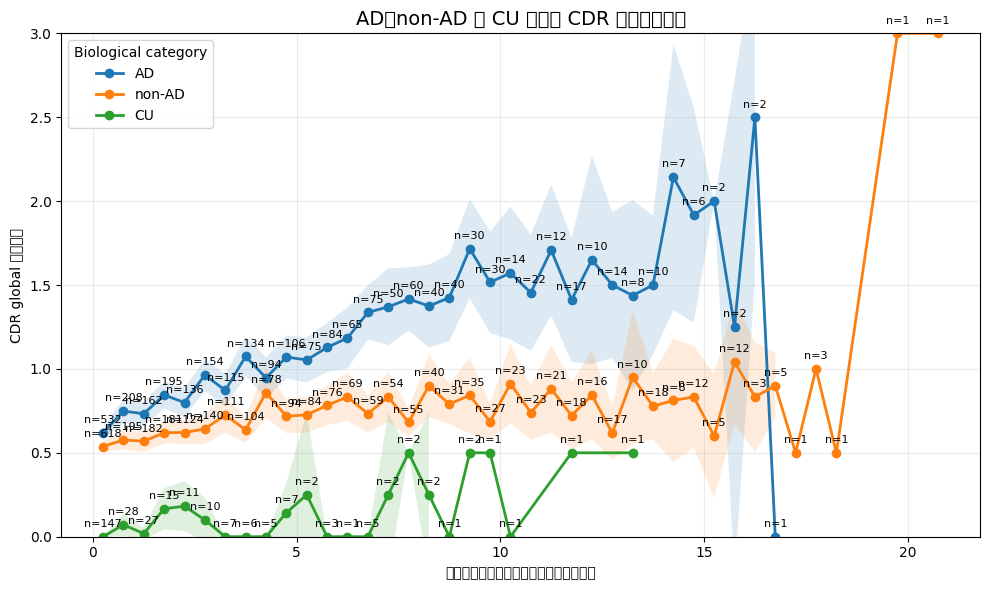

圖片已儲存： D:\school\研究所\馬老師\失智症2\project\results\descriptive_statistics\figures\CDR_longitudinal_trend.png


In [29]:
# CDR 縱向趨勢圖

plot_longitudinal_trend(
    summary_df=plot_cdr,
    outcome_label="CDR global 平均分數",
    title="AD、non-AD 與 CU 三組之 CDR 縱向變化趨勢",
    filename="CDR_longitudinal_trend.png",
    y_limits=(0, 3)
)

In [30]:
# 製作追蹤結構表

def patient_followup_summary(df, prefix):
    patient_level = (
        df.groupby(
            ["patient_id", "bio_category"],
            observed=True
        )
        .agg(
            visit_n=("visit_date", "nunique"),
            followup_years=("time_since_baseline_years", "max")
        )
        .reset_index()
    )

    rows = []

    for variable, label in [
        ("visit_n", f"{prefix} 測量次數"),
        ("followup_years", f"{prefix} 追蹤時間（年）")
    ]:
        row = {
            "指標": label,
            "整體": format_median_iqr(
                patient_level[variable]
            )
        }

        for group in GROUP_ORDER:
            values = patient_level.loc[
                patient_level["bio_category"] == group,
                variable
            ]

            row[group] = format_median_iqr(values)

        row["p 值"] = format_pvalue(
            kruskal_pvalue(
                patient_level.rename(
                    columns={"bio_category": "bio_category"}
                ),
                variable
            )
        )

        rows.append(row)

    return rows


table_followup_rows = []

table_followup_rows.extend(
    patient_followup_summary(
        mmse_long,
        "MMSE/CDR"
    )
)

table_followup_rows.extend(
    patient_followup_summary(
        casi_long,
        "CASI"
    )
)

table_followup = pd.DataFrame(table_followup_rows)

display(table_followup)

,指標,整體,AD,non-AD,CU,p 值
0,MMSE/CDR 測量次數,"3.0 (1.0, 6.0)","4.0 (2.0, 7.0)","3.0 (1.0, 6.0)","1.0 (1.0, 3.0)",<0.001
1,MMSE/CDR 追蹤時間（年）,"2.0 (0.0, 5.5)","2.9 (0.9, 6.2)","2.0 (0.0, 5.8)","0.0 (0.0, 1.7)",<0.001
2,CASI 測量次數,"4.0 (2.0, 7.0)","4.0 (2.0, 7.0)","4.0 (2.0, 7.0)","1.0 (1.0, 3.0)",<0.001
3,CASI 追蹤時間（年）,"3.2 (1.0, 6.7)","3.9 (1.2, 6.8)","3.1 (1.0, 7.0)","0.0 (0.0, 2.7)",<0.001


In [31]:
# 匯出所有表格與畫圖資料 
excel_output = OUTPUT_DIR / "AD_nonAD_CU_descriptive_statistics.xlsx"

with pd.ExcelWriter(
    excel_output,
    engine="openpyxl"
) as writer:

    group_count_table.to_excel(
        writer,
        sheet_name="group_counts",
        index=False
    )

    table1.to_excel(
        writer,
        sheet_name="Table_4_1_baseline",
        index=False
    )

    table_mmse.to_excel(
        writer,
        sheet_name="Table_4_2_MMSE",
        index=False
    )

    table_casi.to_excel(
        writer,
        sheet_name="Table_4_3_CASI",
        index=False
    )

    table_cdr.to_excel(
        writer,
        sheet_name="Table_4_4_CDR",
        index=False
    )

    table_cdr_sob.to_excel(
        writer,
        sheet_name="CDR_SOB_supplement",
        index=False
    )

    table_followup.to_excel(
        writer,
        sheet_name="Table_4_5_followup",
        index=False
    )

    mmse_n_table.to_excel(
        writer,
        sheet_name="MMSE_timepoint_N"
    )

    casi_n_table.to_excel(
        writer,
        sheet_name="CASI_timepoint_N"
    )

    cdr_n_table.to_excel(
        writer,
        sheet_name="CDR_timepoint_N"
    )

    plot_mmse.to_excel(
        writer,
        sheet_name="MMSE_plot_data",
        index=False
    )

    plot_casi.to_excel(
        writer,
        sheet_name="CASI_plot_data",
        index=False
    )

    plot_cdr.to_excel(
        writer,
        sheet_name="CDR_plot_data",
        index=False
    )

print("Excel 已輸出：", excel_output.resolve())

Excel 已輸出： D:\school\研究所\馬老師\失智症2\project\results\descriptive_statistics\AD_nonAD_CU_descriptive_statistics.xlsx


In [32]:
# 輸出 stack data
# 後續 GEE 和 Mixed Effect Model 可以直接接這兩份資料

mmse_stack_output = OUTPUT_DIR / "MMSE_CDR_longitudinal_stack.csv"
casi_stack_output = OUTPUT_DIR / "CASI_longitudinal_stack.csv"

mmse_long.to_csv(
    mmse_stack_output,
    index=False,
    encoding="utf-8-sig"
)

casi_long.to_csv(
    casi_stack_output,
    index=False,
    encoding="utf-8-sig"
)

print("MMSE/CDR stack data：", mmse_stack_output.resolve())
print("CASI stack data：", casi_stack_output.resolve())

MMSE/CDR stack data： D:\school\研究所\馬老師\失智症2\project\results\descriptive_statistics\MMSE_CDR_longitudinal_stack.csv
CASI stack data： D:\school\研究所\馬老師\失智症2\project\results\descriptive_statistics\CASI_longitudinal_stack.csv


In [33]:
# 最後品質檢查

print("========== 最終結果檢查 ==========")

print("\n1. 表 4.1 病患數")
display(
    baseline_df.groupby(
        "bio_category",
        observed=True
    )["patient_id"]
    .nunique()
    .to_frame("patient_n")
)

print("\n2. MMSE 可用觀測")
display(
    mmse_long.groupby(
        "bio_category",
        observed=True
    )["mmse"]
    .count()
    .to_frame("MMSE_available_n")
)

print("\n3. CASI 可用觀測")
display(
    casi_long.groupby(
        "bio_category",
        observed=True
    )["casi_total"]
    .count()
    .to_frame("CASI_available_n")
)

print("\n4. CDR 可用觀測")
display(
    mmse_long.groupby(
        "bio_category",
        observed=True
    )["cdr_global"]
    .count()
    .to_frame("CDR_available_n")
)

print("\n5. 輸出檔案")
for path in OUTPUT_DIR.rglob("*"):
    if path.is_file():
        print(path)

========== 最終結果檢查 ==========

1. 表 4.1 病患數


,patient_n
bio_category,
AD,532
non-AD,618
CU,151



2. MMSE 可用觀測


,MMSE_available_n
bio_category,
AD,2600
non-AD,2646
CU,292



3. CASI 可用觀測


,CASI_available_n
bio_category,
AD,2144
non-AD,2059
CU,150



4. CDR 可用觀測


,CDR_available_n
bio_category,
AD,2600
non-AD,2646
CU,292



5. 輸出檔案
..\results\descriptive_statistics\AD_nonAD_CU_descriptive_statistics.xlsx
..\results\descriptive_statistics\CASI_longitudinal_stack.csv
..\results\descriptive_statistics\MMSE_CDR_longitudinal_stack.csv
..\results\descriptive_statistics\figures\CASI_longitudinal_trend.png
..\results\descriptive_statistics\figures\CDR_longitudinal_trend.png
..\results\descriptive_statistics\figures\MMSE_longitudinal_trend.png
